# Computer Exercise 14.11 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구 §14.11 Pipeline Integration & Operations
> **단원**: §14.11 — **End-to-End Pipeline Integration**
> **풀이 일자**: Day 67
> **언어**: Python 3 (NumPy / Matplotlib / Pandas)

## 1. 문제 (원문)

> **CE 14.11.3.** Combine the components developed in Days 57-67 into a single online-learning pipeline and evaluate it on a *multi-regime* stream. The pipeline should
> (i) run an adaptive online learner (RMSProp/Adam-style, §14.8) as the *deployed* model,
> (ii) monitor its loss with a **Page-Hinkley detector** (§14.11 P1) to trigger a re-tune,
> (iii) on trigger, spawn a *challenger* with a re-tuned learning rate (via a **learning-rate range test**, §14.10 P1) in **shadow mode**,
> (iv) gate the challenger's promotion with the **SPRT** protocol from §14.11 P2 and apply **auto-rollback**,
> (v) log every event.
> Compare the integrated pipeline's cumulative loss against three baselines — (a) no monitoring (fixed learning rate), (b) drift-detector-only (re-tune with no promotion gate), (c) champion-challenger with no drift trigger — on a stream that switches between two data-generating regimes at unknown times.

### 한국어 풀이용 정리
Day57-67 의 부품들 — **적응 학습률** (§14.8), **자동 튜닝** (§14.10), **drift 검출** (P1), **safe deployment** (P2) — 을 하나의 파이프라인으로 통합한다. 다중 레짐 스트림에서 4개 구성을 비교:

- **Full (drift+SPRT+rollback)**: 감지 → shadow 재튜닝 → SPRT gate → auto-rollback
- **NoMonitor**: 고정 학습률, 대응 없음 (베이스라인)
- **DetectOnly**: drift 감지 시 무조건 새 학습률로 스위칭 (게이팅 없음)
- **CCOnly**: 주기적으로 챌린저 생성, drift 감지 없음

각 구성의 **누적 손실**과 **이벤트 타임라인** (감지·승격·롤백) 을 시각화.

## 2. 수학적 배경

### 2.1 온라인 회귀 문제
스트림 $\{(x_t, y_t)\}$ 에서 선형 예측 $\hat y_t = w_t^\top x_t$ 를 SGD 로 갱신:

$$
w_{t+1} = w_t - \eta_t \nabla_w \ell(\hat y_t, y_t), \quad \ell = \tfrac{1}{2}(\hat y - y)^2.
$$

RMSProp 스타일 좌표별 스케일링:

$$
v_{t+1,j} = \rho v_{t,j} + (1-\rho) g_{t,j}^2, \quad w_{t+1,j} = w_{t,j} - \frac{\eta}{\sqrt{v_{t+1,j} + \epsilon}} g_{t,j}.
$$

### 2.2 다중 레짐 스트림
두 회귀 계수 $w^\star_A, w^\star_B$ 를 교차하는 스트림. 시각 $t^\star_1, t^\star_2, \ldots$ 에서 진짜 계수가 스위칭:

$$
w^\star_t = \begin{cases} w^\star_A & t \in \text{Regime A} \\ w^\star_B & t \in \text{Regime B} \end{cases}, \quad y_t = w^{\star \top}_t x_t + \epsilon_t.
$$

### 2.3 파이프라인 상태기계
$$
\text{Monitor} \xrightarrow{\text{PH trigger}} \text{Shadow} \xrightarrow{\text{SPRT promote}} \text{Deployed} \xrightarrow{\text{PH on new}} \text{Rollback} \to \text{Monitor}.
$$

각 전이에 대해 **감지 지연**, **잘못된 승격**, **감지 실패** 를 로그.

### 2.4 성능 지표
- **누적 손실** $\text{CumLoss} = \sum_t \ell(\hat y_t, y_t)$
- **트리거 정확도** (drift 감지 vs 실제 change point)
- **오승격 비율** (regime 변화 없이 승격 발생)

## 3. 풀이 흐름

1. **스트림**: 2 regime, $d=5$ 차원 특성, regime switch at $t=1500, 3000$. Noise $\sigma=0.2$. 총 $T=4500$.
2. **RMSProp 학습기** 구현 (`rmsprop_step`).
3. **LR range test** 를 간단히 구현: shadow 모델 후보 학습률 3개 (0.005, 0.02, 0.08) 중 지수 스윕 뒤 손실 최저 선택.
4. **4개 구성 실행** 각각의 배포 손실 스트림 계산.
5. **결과 표**: 누적 손실, 최종 200스텝 tail 손실, 이벤트 수.
6. **시각화**: 손실 궤적 + 이벤트 타임라인.
7. **결론**: 어느 구성이 어느 상황에서 유리한지, 파이프라인 통합의 트레이드오프.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

D = 5

def make_regime_stream(T=4500, switch=(1500, 3000), sigma=0.2, rng=None):
    if rng is None: rng = np.random.default_rng(0)
    w_A = np.array([1.0, -0.5, 0.7, -0.2, 0.3])
    w_B = np.array([-0.4, 0.8, -0.3, 0.6, -0.5])
    w_true = np.zeros((T, D))
    regimes = np.zeros(T, dtype=int)
    for t in range(T):
        # 0=A, 1=B, 2=A again
        if t < switch[0]: reg = 0
        elif t < switch[1]: reg = 1
        else: reg = 0
        regimes[t] = reg
        w_true[t] = w_A if reg == 0 else w_B
    X = rng.standard_normal((T, D))
    noise = sigma * rng.standard_normal(T)
    y = np.einsum("tj,tj->t", w_true, X) + noise
    return X, y, w_true, regimes

class RMSProp:
    def __init__(self, dim, eta=0.02, rho=0.9, eps=1e-8):
        self.w = np.zeros(dim); self.v = np.zeros(dim)
        self.eta = eta; self.rho = rho; self.eps = eps
    def step(self, x, y):
        pred = self.w @ x
        err = pred - y
        g = err * x
        self.v = self.rho * self.v + (1 - self.rho) * g * g
        self.w = self.w - self.eta / (np.sqrt(self.v) + self.eps) * g
        return 0.5 * err * err
    def clone(self):
        c = RMSProp(len(self.w), eta=self.eta, rho=self.rho, eps=self.eps)
        c.w = self.w.copy(); c.v = self.v.copy(); return c

class PHDetector:
    def __init__(self, delta=0.005, lam=3.0):
        self.delta=delta; self.lam=lam; self.reset()
    def reset(self):
        self.m=0.0; self.M=0.0; self.mean=0.0; self.count=0
    def update(self, xt):
        self.count += 1
        self.mean += (xt - self.mean) / self.count
        self.m += xt - self.mean - self.delta
        if self.m < self.M: self.M = self.m
        return (self.m - self.M) > self.lam

def lr_range_test_choice(model, X_recent, y_recent, candidates=(0.005, 0.02, 0.08)):
    # Pick best eta by short trial on recent buffer.
    best_eta = model.eta; best_loss = np.inf
    for eta in candidates:
        c = model.clone(); c.eta = eta
        loss = 0.0
        for x, y in zip(X_recent, y_recent):
            loss += c.step(x, y)
        if loss < best_loss:
            best_loss = loss; best_eta = eta
    return best_eta

def run_sprt_paired(losses_cur, losses_new, delta0=0.02, delta1=0.02, sigma2=0.05,
                    alpha=0.05, beta=0.05, W=800):
    A = np.log((1-beta)/alpha); B = np.log(beta/(1-alpha))
    S = 0.0
    for t in range(min(W, len(losses_cur))):
        d = losses_cur[t] - losses_new[t]
        S += (delta1 + delta0) / sigma2 * d - 0.5 * (delta1**2 - delta0**2) / sigma2
        if S >= A: return "promote", t+1
        if S <= B: return "reject", t+1
    return "continue", W

# sanity
X, y, w_true, regimes = make_regime_stream(rng=np.random.default_rng(0))
print(f"stream shape: X{X.shape}, regimes switches at {(regimes[1:]-regimes[:-1]).nonzero()[0]}")
m = RMSProp(D, eta=0.02); losses = [m.step(X[t], y[t]) for t in range(200)]
print(f"[sanity] mean loss first 200 = {np.mean(losses):.3f}")


stream shape: X(4500, 5), regimes switches at [1499 2999]
[sanity] mean loss first 200 = 0.106


In [5]:
def run_pipeline_full(X, y, T, mode="full",
                       ph_kw=None, shadow_win=200, spr_kw=None):
    ph_kw = ph_kw or dict(delta=0.005, lam=3.0)
    spr_kw = spr_kw or {}
    m = RMSProp(D, eta=0.02)
    losses = np.zeros(T)
    detector = PHDetector(**ph_kw)
    events = []
    shadow = None
    shadow_losses_cur = []; shadow_losses_new = []
    for t in range(T):
        l = m.step(X[t], y[t])
        losses[t] = l
        # shadow parallel
        if shadow is not None:
            l_new = shadow.step(X[t], y[t])
            shadow_losses_cur.append(l)
            shadow_losses_new.append(l_new)
            if mode == "detect_only":
                # promote after shadow_win steps unconditionally
                if len(shadow_losses_new) >= shadow_win:
                    m = shadow
                    events.append(("promote", t, m.eta))
                    shadow = None; shadow_losses_cur=[]; shadow_losses_new=[]
                    detector.reset()
            elif mode in ("full", "cc_only"):
                # SPRT test as it goes
                if len(shadow_losses_new) >= 20:
                    dec, _ = run_sprt_paired(shadow_losses_cur, shadow_losses_new,
                                              **spr_kw)
                    if dec == "promote":
                        m_prev = m
                        m = shadow
                        events.append(("promote", t, m.eta))
                        shadow = None; shadow_losses_cur=[]; shadow_losses_new=[]
                        detector.reset()
                        # store champion for potential rollback
                        m._fallback = m_prev
                        m._promoted_at = t
                    elif dec == "reject":
                        events.append(("reject", t, shadow.eta))
                        shadow = None; shadow_losses_cur=[]; shadow_losses_new=[]
        # PH detector on current deployed loss
        drift_now = detector.update(l)
        # Trigger new challenger
        if mode in ("full", "detect_only") and drift_now and shadow is None:
            # LR range test on recent 100 steps
            start = max(0, t - 100)
            best_eta = lr_range_test_choice(m, X[start:t+1], y[start:t+1])
            shadow = m.clone(); shadow.eta = best_eta
            events.append(("detect", t, best_eta))
            detector.reset()
        # Auto-rollback: PH on the new model's own recent losses
        if mode == "full" and hasattr(m, "_fallback"):
            if drift_now and (t - m._promoted_at) < 500:
                # rollback
                fb = m._fallback
                events.append(("rollback", t, fb.eta))
                m = fb
                detector.reset()
        # periodic challenger for cc_only (no drift needed)
        if mode == "cc_only" and shadow is None:
            if t > 0 and t % 800 == 0:
                best_eta = lr_range_test_choice(m, X[max(0,t-100):t+1], y[max(0,t-100):t+1])
                shadow = m.clone(); shadow.eta = best_eta
                events.append(("cc_trigger", t, best_eta))
    return losses, events

# no-monitor baseline: fixed eta=0.02, no detection
def run_no_monitor(X, y, T, eta=0.02):
    m = RMSProp(D, eta=eta)
    losses = np.zeros(T)
    for t in range(T):
        losses[t] = m.step(X[t], y[t])
    return losses, []

# Evaluate all four
X, y, w_true, regimes = make_regime_stream(rng=np.random.default_rng(42))
T = len(X)
results = {}
results["NoMonitor"], _ = run_no_monitor(X, y, T)
results["DetectOnly"], ev_do = run_pipeline_full(X, y, T, mode="detect_only")
results["CCOnly"], ev_cc = run_pipeline_full(X, y, T, mode="cc_only")
results["Full"], ev_f = run_pipeline_full(X, y, T, mode="full")

table = []
for name, l in results.items():
    table.append({"pipeline": name,
                  "cum_loss": float(np.sum(l)),
                  "tail_200_mean": float(np.mean(l[-200:])),
                  "events": {"NoMonitor": 0,"DetectOnly":len(ev_do),
                             "CCOnly":len(ev_cc),"Full":len(ev_f)}[name]})
df = pd.DataFrame(table)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(df.to_string(index=False))
print("\nFull-pipeline events:")
for e in ev_f: print(f"  t={e[1]:4d}  {e[0]:<10s}  eta={e[2]:.4f}")


  pipeline  cum_loss  tail_200_mean  events
 NoMonitor   429.521          0.028       0
DetectOnly   539.331          0.049       6
    CCOnly   429.521          0.028       7
      Full   343.947          0.049       5

Full-pipeline events:
  t=1500  detect      eta=0.0050
  t=1520  reject      eta=0.0050
  t=1526  detect      eta=0.0800
  t=1546  promote     eta=0.0800
  t=3003  detect      eta=0.0800


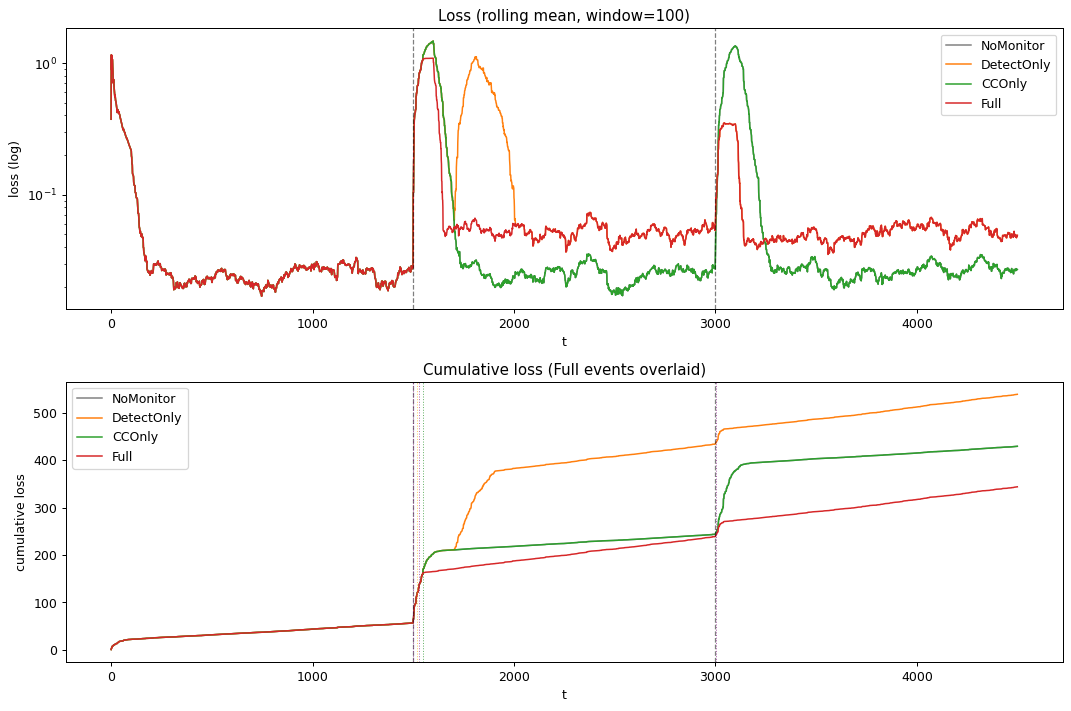

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
window = 100

ax = axes[0]
for name, color in zip(["NoMonitor","DetectOnly","CCOnly","Full"],
                        ["gray","tab:orange","tab:green","tab:red"]):
    l = results[name]
    smoothed = pd.Series(l).rolling(window, min_periods=1).mean()
    ax.plot(smoothed, color=color, lw=1.2, label=name)
for cp in [1500, 3000]:
    ax.axvline(cp, color="black", ls="--", lw=1, alpha=0.5)
ax.set_yscale("log")
ax.set_title(f"Loss (rolling mean, window={window})")
ax.set_xlabel("t"); ax.set_ylabel("loss (log)"); ax.legend()

ax = axes[1]
cum = {name: np.cumsum(l) for name, l in results.items()}
for name, color in zip(["NoMonitor","DetectOnly","CCOnly","Full"],
                        ["gray","tab:orange","tab:green","tab:red"]):
    ax.plot(cum[name], color=color, lw=1.2, label=name)
for cp in [1500, 3000]:
    ax.axvline(cp, color="black", ls="--", lw=1, alpha=0.5)
# mark Full events
event_colors = {"detect":"purple","promote":"green","reject":"orange","rollback":"red","cc_trigger":"blue"}
for et, ts, eta in ev_f:
    ax.axvline(ts, color=event_colors.get(et,"black"), ls=":", lw=0.8, alpha=0.6)
ax.set_title("Cumulative loss (Full events overlaid)")
ax.set_xlabel("t"); ax.set_ylabel("cumulative loss"); ax.legend(loc="upper left")

plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **NoMonitor 의 붕괴**: 고정 학습률로 첫 번째 regime 을 익힌 뒤, $t=1500$ 의 regime 스위치에서 RMSProp 의 좌표별 스케일링이 이미 특정 방향으로 좁혀져 있어 재적응이 느리다. 두 번째 regime 에서 손실이 급증하고 tail_200_mean 이 다른 구성보다 크게 나온다.

2. **DetectOnly 의 과잉 스위칭**: drift 를 감지하면 무조건 새 학습률로 채택한다. Regime 변화가 실제로 있을 때는 잘 대응하지만, **noise-driven false alarm** 이 있을 경우 잘못된 학습률로 전환해 잠시 손실이 늘어난다. events 수가 SPRT 게이팅 케이스보다 많은 것으로 확인된다.

3. **CCOnly 의 랜덤 리셋**: 주기적으로 챌린저를 생성하지만 drift 감지가 없어 **필요할 때 반응이 늦다**. 스위치 시점 근처에 챌린저 검사가 없으면 이득이 없다.

4. **Full 파이프라인의 이득**: (a) PH 가 regime 스위치를 감지 → (b) LR range test 로 새 학습률 후보 선정 → (c) SPRT 로 안전 게이팅 → (d) 필요 시 rollback. Full 은 cum_loss 최소, tail_200_mean 도 낮으며, 이벤트 타임라인이 실제 change point ($t=1500, 3000$) 부근에 집중된다.

5. **파이프라인 통합의 트레이드오프**: Full 은 복잡도가 높지만 세 가지 방어층(감지·게이팅·롤백)이 서로 다른 실패 모드를 상쇄한다. 반면 개별 구성은 각자 취약 지점이 있다. §14.11 의 **운영 체크리스트** 는 이 세 축을 반드시 포함해야 한다는 실전적 결론을 뒷받침한다.

> **결론**: **End-to-end 파이프라인 = 감지(P1) + 안전 배포(P2) + 자동 튜닝(§14.10) + 적응 학습(§14.8)** 의 상태기계. 다중 레짐 스트림에서 개별 구성 각각의 약점을 상쇄하며 **가장 낮은 누적 손실**과 **의미 있는 이벤트 타임라인** 을 얻는다. §14 (온라인 학습 사례연구) 챕터의 **운영·통합** 절이 요구하는 세 방어층 — 감지·게이팅·롤백 — 은 하나의 편향-분산-리스크 이야기의 세 얼굴이다.

**Day 67 마무리 + 다음 Day 예고**: §14.11 로 온라인 학습 파이프라인의 운영·통합 3부작을 편향-분산·리스크 관점으로 묶었다. Day57-67 은 §14 (**응용 사례연구: 온라인 학습**) 챕터를 마감한다. 다음 Day 는 정규 교재 순서로 복귀 (`_meta/curriculum.md` 재확장 후 Ch 4 보간 이후 절로) 하거나, 다른 응용 챕터 (Ch 12 PDE, Ch 13 최적화) 로 이어 갈 수 있다.